# Clasificación de texto

## Descripción del ejercicio
El conjunto de datos utilizado en este ejemplo proviene del [Unhealthy Comments Corpus](https://github.com/conversationai/unhealthy-conversations), una colección de 44,000 comentarios que han sido anotados para una variedad de aspectos sutiles de discurso tóxico y problemático, incluyendo sarcasmo, antagonismo y condescendencia. Este conjunto de datos ha sido utilizado en la construcción de [Perspective API](https://perspectiveapi.com), una herramienta automática para la gestión y mejora de las conversaciones online.

Los datos están descritos en: 
> Price, I., Gifford-Moore, J., Fleming, J., Musker, S., Roichman, M., Sylvain, G., Thain, N., Dixon, L., & Sorensen, J. (2020). Six attributes of unhealthy conversation. [arXiv 2010.07410](https://arxiv.org/abs/2010.07410). 

Nos interesan las columnas `comment` y `healthy`:
- `comment`: texto del comentario, en inglés
- `healthy`: valor {0, 1}, correspondiente a comentario _problemático_ o no

# Carga de datos

In [1]:
train_datafile = 'data/train.csv'
validation_datafile = 'data/validation.csv'
test_datafile = 'data/test.csv'

In [2]:
import pandas as pd
data_train = pd.read_csv(train_datafile)
data_train


,_unit_id,_trusted_judgments,comment,antagonize,antagonize:confidence,condescending,condescending:confidence,dismissive,dismissive:confidence,generalisation,generalisation:confidence,generalisation_unfair,generalisation_unfair:confidence,healthy,healthy:confidence,hostile,hostile:confidence,sarcastic,sarcastic:confidence
0,2319157561,4,"Three marriages, several bankrupt periods, inh...",0,1.0000,0,1.0000,0,1.0000,0,1.0000,0.0,1.0,1,0.7578,0,0.7565,0,1.0000
1,1739464982,4,The sense of entitlement among high school 'jo...,0,0.7634,0,0.7634,0,0.7634,0,1.0000,0.0,1.0,1,0.7634,0,0.7634,0,0.7634
2,1739457583,5,So what? He was just stating the obvious.,0,0.8121,0,0.5928,0,0.8043,0,1.0000,0.0,1.0,1,0.6163,0,1.0000,0,1.0000
3,2319156950,40,"If one is a Con, why yes, one would honk. Loud...",0,0.8508,0,0.8867,0,0.9239,0,0.8863,0.0,1.0,1,0.8508,0,0.9641,0,0.8868
4,2327196492,3,Ooohhh... It's Wendy Whiner... making sure to ...,0,1.0000,0,1.0000,0,1.0000,0,1.0000,0.0,1.0,1,1.0000,0,1.0000,0,1.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35498,2327179313,3,"Okay, make that ""write a book"" Fingers don't a...",0,1.0000,0,1.0000,0,1.0000,0,1.0000,0.0,1.0,1,1.0000,0,1.0000,0,1.0000
35499,2164631772,3,"It was Americans in Alberta, not the governmen...",0,1.0000,0,1.0000,0,1.0000,0,1.0000,0.0,1.0,1,1.0000,0,1.0000,0,1.0000
35500,1739460377,3,Whiner: Your air force consists of paper power...,0,1.0000,0,1.0000,0,1.0000,0,1.0000,0.0,1.0,1,1.0000,0,1.0000,0,1.0000
35501,1739461160,5,OUTSTANDING EDITORIAL!,0,0.7934,0,1.0000,0,1.0000,0,1.0000,0.0,1.0,1,0.7934,0,1.0000,0,1.0000


Histograma con número de instancias de cada clase, después de convertir los valores {0, 1} a etiquetas.

Different values of the 'healthy' column: [1 0]


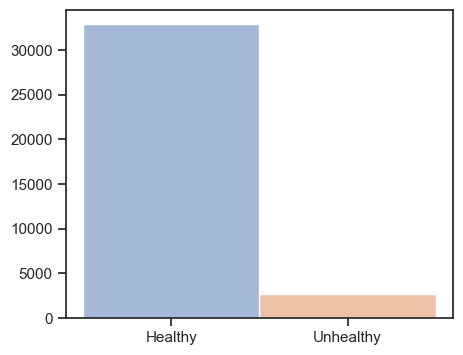

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Comprobar número de valores de la columna 'healthy'
unique_healthy_values = data_train['healthy'].unique()
print("Different values of the 'healthy' column:", unique_healthy_values)

# Recodificar columna 'healthy' en una nueva columna 'healthy_label'
data_train['healthy_label'] = data_train['healthy'].map({1: 'Healthy', 0: 'Unhealthy'})
data_train_selection = data_train[['comment', 'healthy_label']]

# Mostrar histograma
plt.figure(figsize=(5, 4))
sns.set_theme(style="ticks")
sns.histplot(data=data_train_selection, x='healthy_label', hue='healthy_label', legend=False)
plt.xlabel('')
plt.ylabel('')
plt.show()